# Chapter 42 — Exponential Growth

> **Prerequisites:** ch041 (Exponents and Powers), ch026 (Real Numbers), ch022 (Natural Numbers)  
> **You will learn:**
> - What distinguishes exponential growth from linear and polynomial growth
> - The continuous exponential function `e^x` and why Euler's number appears naturally
> - Doubling time, half-life, and the rule of 72
> - How exponential growth manifests in computing (algorithm complexity, data sizes, Moore's law)
> - Exponential decay as the mirror image
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Exponential growth is characterized by one property: **the rate of increase is proportional to the current value**.

Compare:
- **Linear growth:** add the same amount each step. Bank account with fixed $100/year deposit.
- **Polynomial growth:** `n^2`, `n^3` — increases, but the rate of the rate is eventually constant.
- **Exponential growth:** multiply by the same factor each step. Bank account with 10% compound interest.

The discrete form: start with `P₀`, multiply by factor `r` each period:
```
P(n) = P₀ × r^n
```

The continuous form: after time `t` with continuous growth rate `k`:
```
P(t) = P₀ × e^(kt)
```

Both are instances of `b^x` from ch041, but now `x` is a continuous variable — time, number of operations, problem size.

**Why it matters for programmers:**
- An `O(2^n)` algorithm is exponential — infeasible for `n > 50`.
- Virus spread, population dynamics, compound interest: all exponential.
- The number of possible states in a system of `n` binary variables is `2^n`.

**Common misconception:** People routinely underestimate exponential growth. The famous rice-and-chessboard problem: placing 1 grain on square 1, 2 on square 2, doubling each time, the 64th square requires `2^63 ≈ 9.2 × 10^18` grains — more rice than has ever been grown on Earth.

---

## 2. Intuition & Mental Models

**Physical analogy:** Think of exponential growth as compound interest on a debt that constantly accrues. Every dollar of debt generates more interest, which becomes more debt, which generates more interest. The amount you owe grows in proportion to how much you currently owe — not in proportion to how long you've owed it.

**Computational analogy:** Think of `2^n` as the size of the binary search space for `n` bits. Adding one bit *doubles* the number of possible states. This is why cracking an n-bit password takes exponential time in `n`.

**The differential equation perspective:** Exponential growth is the unique solution to:
```
dP/dt = k × P
```
"The rate of change equals k times the current value." *(The language of derivatives will be formalized in ch204 — Derivative Concept, but the intuition is available now.)*

**Why `e`?** Euler's number `e ≈ 2.71828` is the base where the rate of change of `e^x` equals `e^x` itself — the growth rate and the current value are the same function. This is the "natural" base for continuous growth. *(We derive this properly in ch043 — Logarithms Intuition.)*

**Doubling time:** If growth rate per period is `r`, then the doubling time is `log₂(2) / log₂(r) = 1 / log₂(r)` periods. The **Rule of 72**: at `p%` growth per period, doubling time ≈ `72 / p`. At 10%/year, money doubles in ~7.2 years.

---

## 3. Visualization

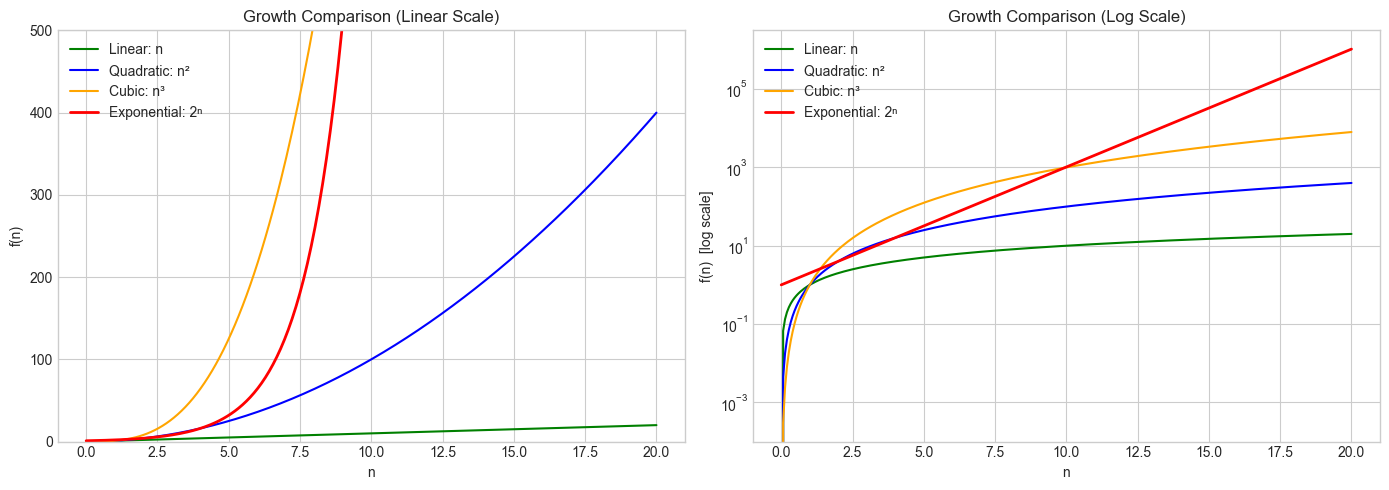

In [1]:
# --- Visualization: Linear vs polynomial vs exponential growth ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

n = np.linspace(0, 20, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Linear scale (exponential dominates quickly) ---
ax = axes[0]
ax.plot(n, n,         label='Linear: n',       color='green')
ax.plot(n, n**2,      label='Quadratic: n²',   color='blue')
ax.plot(n, n**3,      label='Cubic: n³',       color='orange')
ax.plot(n, 2**n,      label='Exponential: 2ⁿ', color='red', linewidth=2)
ax.set_ylim(0, 500)
ax.set_title('Growth Comparison (Linear Scale)')
ax.set_xlabel('n')
ax.set_ylabel('f(n)')
ax.legend()

# --- Panel 2: Log scale (straightens exponential to a line) ---
ax = axes[1]
ax.plot(n, n,         label='Linear: n',       color='green')
ax.plot(n, n**2,      label='Quadratic: n²',   color='blue')
ax.plot(n, n**3,      label='Cubic: n³',       color='orange')
ax.plot(n, 2**n,      label='Exponential: 2ⁿ', color='red', linewidth=2)
ax.set_yscale('log')
ax.set_title('Growth Comparison (Log Scale)')
ax.set_xlabel('n')
ax.set_ylabel('f(n)  [log scale]')
ax.legend()

plt.tight_layout()
plt.show()

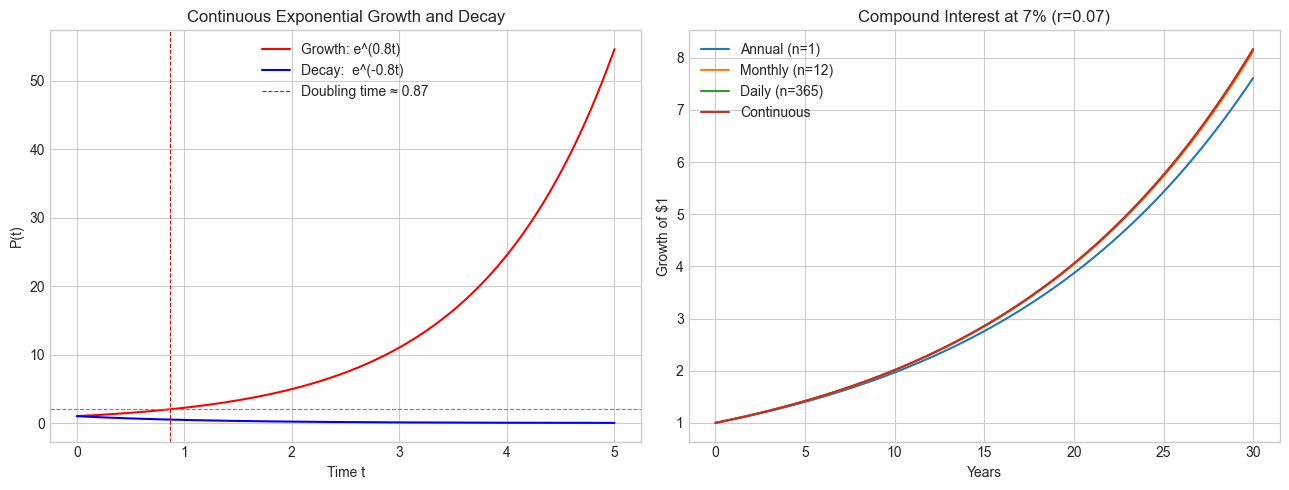

In [2]:
# --- Visualization: Continuous exponential and decay; doubling time ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

t = np.linspace(0, 5, 500)
P0 = 1.0          # initial value
k_growth = 0.8    # growth rate
k_decay  = -0.8   # decay rate

P_growth = P0 * np.exp(k_growth * t)
P_decay  = P0 * np.exp(k_decay  * t)
doubling_time = np.log(2) / k_growth  # exact formula

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(t, P_growth, color='red',   label=f'Growth: e^({k_growth}t)')
ax.plot(t, P_decay,  color='blue',  label=f'Decay:  e^({k_decay}t)')
ax.axhline(2 * P0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(doubling_time, color='red', linestyle='--', linewidth=0.8,
           label=f'Doubling time ≈ {doubling_time:.2f}')
ax.set_title('Continuous Exponential Growth and Decay')
ax.set_xlabel('Time t')
ax.set_ylabel('P(t)')
ax.legend()

# Compound interest: annual compounding vs continuous
ax = axes[1]
years = np.linspace(0, 30, 300)
r = 0.07  # 7% annual rate
for n_per_year, label in [(1, 'Annual (n=1)'), (12, 'Monthly (n=12)'),
                           (365, 'Daily (n=365)'), (np.inf, 'Continuous')]:
    if n_per_year == np.inf:
        vals = np.exp(r * years)
    else:
        vals = (1 + r / n_per_year) ** (n_per_year * years)
    ax.plot(years, vals, label=label)
ax.set_title(f'Compound Interest at {int(r*100)}% (r={r})')
ax.set_xlabel('Years')
ax.set_ylabel('Growth of $1')
ax.legend()

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

### Discrete exponential

```
P(n) = P₀ × r^n

Where:
  P₀ = initial value
  r  = growth factor per step (r > 1: growth, 0 < r < 1: decay)
  n  = number of steps (non-negative integer)
```

### Continuous exponential

```
P(t) = P₀ × e^(kt)

Where:
  P₀ = initial value at t=0
  k  = continuous growth rate (k > 0: growth, k < 0: decay)
  t  = continuous time variable
  e  ≈ 2.71828 (Euler's number)
```

### Relationship between discrete and continuous forms

The two forms are equivalent when:
```
r = e^k    ↔    k = ln(r)
```

A factor of `r = 2` (doubling per step) corresponds to `k = ln(2) ≈ 0.693`.

### Compound interest — deriving `e`

Compound `n` times per year at annual rate `r`:
```
P(1 year) = P₀ × (1 + r/n)^n
```

As `n → ∞` (continuous compounding):
```
lim_{n→∞} (1 + r/n)^n = e^r
```

For `r = 1`: `lim_{n→∞} (1 + 1/n)^n = e`. This is one definition of Euler's number.

In [3]:
# --- Verify the limit definition of e ---
import numpy as np

print("Approximating e via (1 + 1/n)^n")
print("-" * 45)
for n in [1, 10, 100, 1_000, 1_000_000, 1_000_000_000]:
    approx = (1 + 1/n) ** n
    print(f"n = {n:>12,}:  (1+1/n)^n = {approx:.10f}")
print(f"\nnp.e           =             {np.e:.10f}")
print("\nNote: the convergence is slow (only ~log10(n) decimal digits per order of magnitude)")

Approximating e via (1 + 1/n)^n
---------------------------------------------
n =            1:  (1+1/n)^n = 2.0000000000
n =           10:  (1+1/n)^n = 2.5937424601
n =          100:  (1+1/n)^n = 2.7048138294
n =        1,000:  (1+1/n)^n = 2.7169239322
n =    1,000,000:  (1+1/n)^n = 2.7182804691
n = 1,000,000,000:  (1+1/n)^n = 2.7182820520

np.e           =             2.7182818285

Note: the convergence is slow (only ~log10(n) decimal digits per order of magnitude)


---

## 5. Python Implementation

In [4]:
# --- Implementation: Discrete and continuous exponential models ---
import numpy as np

def discrete_exponential(P0, r, n_steps):
    """
    Simulate discrete exponential growth/decay.

    P(n) = P0 * r^n

    Args:
        P0:      initial value
        r:       growth factor per step (r > 1 grows, 0 < r < 1 decays)
        n_steps: number of steps (non-negative integer)

    Returns:
        Array of values P(0), P(1), ..., P(n_steps)
    """
    steps = np.arange(0, n_steps + 1)
    return P0 * r ** steps


def continuous_exponential(P0, k, t_max, n_points=500):
    """
    Evaluate continuous exponential model P(t) = P0 * e^(kt).

    Args:
        P0:       initial value at t=0
        k:        continuous rate (positive=growth, negative=decay)
        t_max:    upper time limit
        n_points: resolution

    Returns:
        t array, P(t) array
    """
    t = np.linspace(0, t_max, n_points)
    P = P0 * np.exp(k * t)
    return t, P


def doubling_time(r=None, k=None):
    """
    Compute doubling time from either a discrete factor r or continuous rate k.
    Uses: T_double = ln(2) / k  (continuous)  or  log(2)/log(r) (discrete)

    Args:
        r: discrete growth factor (> 1)
        k: continuous growth rate (> 0)

    Returns:
        Doubling time (in same units as the growth rate)
    """
    if k is not None:
        return np.log(2) / k
    elif r is not None:
        return np.log(2) / np.log(r)
    else:
        raise ValueError("Provide either r or k")


# Demonstrations
print("Discrete model: bacterial colony doubling every hour")
colony = discrete_exponential(P0=100, r=2, n_steps=10)
for i, v in enumerate(colony):
    print(f"  Hour {i:2d}: {v:>10,.0f} bacteria")

print(f"\nDoubling time check: {doubling_time(r=2):.4f} steps  (expected 1.0)")

print("\nRule of 72 validation (7% growth):")
exact = doubling_time(k=0.07)
rule_of_72 = 72 / 7
print(f"  Exact doubling time: {exact:.4f} years")
print(f"  Rule of 72 estimate: {rule_of_72:.4f} years")
print(f"  Error: {abs(exact - rule_of_72)/exact * 100:.2f}%")

Discrete model: bacterial colony doubling every hour
  Hour  0:        100 bacteria
  Hour  1:        200 bacteria
  Hour  2:        400 bacteria
  Hour  3:        800 bacteria
  Hour  4:      1,600 bacteria
  Hour  5:      3,200 bacteria
  Hour  6:      6,400 bacteria
  Hour  7:     12,800 bacteria
  Hour  8:     25,600 bacteria
  Hour  9:     51,200 bacteria
  Hour 10:    102,400 bacteria

Doubling time check: 1.0000 steps  (expected 1.0)

Rule of 72 validation (7% growth):
  Exact doubling time: 9.9021 years
  Rule of 72 estimate: 10.2857 years
  Error: 3.87%


---

## 6. Experiments

In [5]:
# --- Experiment 1: The chessboard problem — intuition calibration ---
# Hypothesis: 2^63 is incomprehensibly large.
# Let's compute it and compare to real quantities.
# Try changing: GRAIN_MASS_GRAMS to compare to other large quantities

import numpy as np

GRAIN_MASS_GRAMS = 0.03     # mass of one grain of rice in grams  <-- modify this
EARTH_MASS_KG    = 5.97e24  # mass of Earth in kg

total_grains = sum(2**i for i in range(64))
total_mass_g = total_grains * GRAIN_MASS_GRAMS
total_mass_kg = total_mass_g / 1000

print(f"Total grains on chessboard: {total_grains:.3e}")
print(f"= 2^63 + 2^62 + ... + 1 = 2^64 - 1")
print(f"\nTotal mass: {total_mass_g:.3e} grams = {total_mass_kg:.3e} kg")
print(f"Earth's mass:             {EARTH_MASS_KG:.3e} kg")
print(f"Ratio (rice / Earth):     {total_mass_kg / EARTH_MASS_KG:.3e}")
print(f"\nRice mass is {total_mass_kg / EARTH_MASS_KG:.1e} × Earth's mass.")

Total grains on chessboard: 1.845e+19
= 2^63 + 2^62 + ... + 1 = 2^64 - 1

Total mass: 5.534e+17 grams = 5.534e+14 kg
Earth's mass:             5.970e+24 kg
Ratio (rice / Earth):     9.270e-11

Rice mass is 9.3e-11 × Earth's mass.


In [6]:
# --- Experiment 2: Algorithm complexity — when does O(2^n) become infeasible? ---
# Hypothesis: An O(2^n) algorithm becomes unusable far before an O(n^3) one.
# Assume 10^9 operations per second.
# Try changing: OPS_PER_SEC to see how hardware improvements help (or don't)

import numpy as np

OPS_PER_SEC = 1e9        # <-- modify this (try 1e12 for a supercomputer)
SECONDS_IN_YEAR = 3.15e7

print(f"Assumed speed: {OPS_PER_SEC:.0e} operations/second")
print(f"{'n':>5} {'O(n^2)':>15} {'O(n^3)':>15} {'O(2^n)':>20}")
print("-" * 60)

def format_time(seconds):
    if seconds < 1e-6:   return f"{seconds*1e9:.2f} ns"
    if seconds < 1e-3:   return f"{seconds*1e6:.2f} μs"
    if seconds < 1:      return f"{seconds*1e3:.2f} ms"
    if seconds < 60:     return f"{seconds:.2f} s"
    if seconds < 3600:   return f"{seconds/60:.2f} min"
    if seconds < 86400:  return f"{seconds/3600:.2f} hr"
    if seconds < SECONDS_IN_YEAR: return f"{seconds/86400:.2f} days"
    years = seconds / SECONDS_IN_YEAR
    if years < 1e6:      return f"{years:.2e} years"
    return f"{years:.2e} years"

for n in [10, 20, 30, 40, 50, 60, 100]:
    t_n2 = n**2    / OPS_PER_SEC
    t_n3 = n**3    / OPS_PER_SEC
    t_2n = 2.0**n  / OPS_PER_SEC
    print(f"{n:>5} {format_time(t_n2):>15} {format_time(t_n3):>15} {format_time(t_2n):>20}")

Assumed speed: 1e+09 operations/second
    n          O(n^2)          O(n^3)               O(2^n)
------------------------------------------------------------
   10       100.00 ns         1.00 μs              1.02 μs
   20       400.00 ns         8.00 μs              1.05 ms
   30       900.00 ns        27.00 μs               1.07 s
   40         1.60 μs        64.00 μs            18.33 min
   50         2.50 μs       125.00 μs           13.03 days
   60         3.60 μs       216.00 μs       3.66e+01 years
  100        10.00 μs         1.00 ms       4.02e+13 years


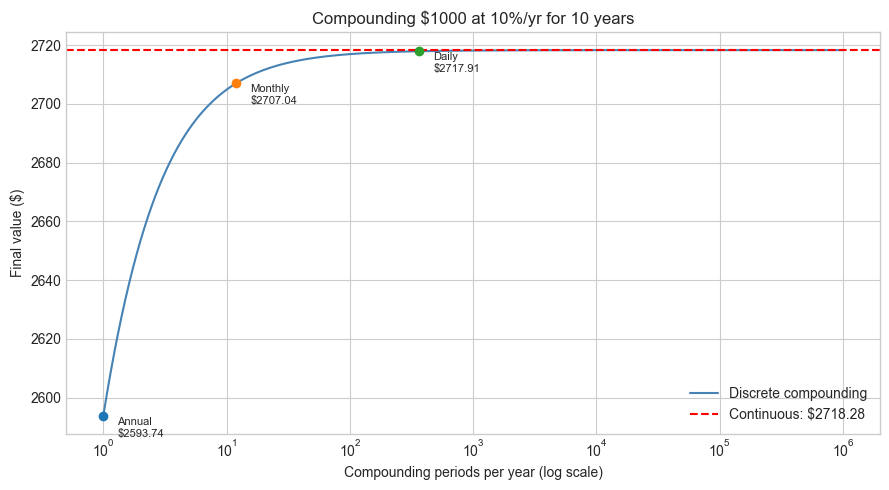

In [7]:
# --- Experiment 3: Compounding frequency and convergence to e^r ---
# Hypothesis: More frequent compounding converges to continuous compounding,
# but with diminishing returns.
# Try changing: ANNUAL_RATE and YEARS

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

ANNUAL_RATE = 0.10   # <-- modify this (try 0.05, 0.20)
YEARS       = 10     # <-- modify this
P0          = 1000   # initial principal

n_values = np.logspace(0, 6, 200)  # 1 to 10^6 compounding periods per year
final_values = P0 * (1 + ANNUAL_RATE / n_values) ** (n_values * YEARS)
continuous   = P0 * np.exp(ANNUAL_RATE * YEARS)

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(n_values, final_values, color='steelblue', label='Discrete compounding')
ax.axhline(continuous, color='red', linestyle='--', label=f'Continuous: ${continuous:.2f}')

for n, label in [(1, 'Annual'), (12, 'Monthly'), (365, 'Daily')]:
    val = P0 * (1 + ANNUAL_RATE / n) ** (n * YEARS)
    ax.scatter([n], [val], zorder=5)
    ax.annotate(f'{label}\n${val:.2f}', (n, val), textcoords='offset points',
                xytext=(10, -15), fontsize=8)

ax.set_title(f'Compounding ${P0} at {ANNUAL_RATE*100:.0f}%/yr for {YEARS} years')
ax.set_xlabel('Compounding periods per year (log scale)')
ax.set_ylabel(f'Final value ($)')
ax.legend()
plt.tight_layout()
plt.show()

---

## 7. Exercises

**Easy 1.** A virus doubles in population every 3 hours. Starting from 500 cells, write a function that returns the population after `t` hours (continuous model). How many cells after 24 hours?

**Easy 2.** Use the Rule of 72 to estimate: at 6% annual growth, how long to double? At 9%? Verify with the exact formula `ln(2)/k`.

**Medium 1.** Carbon-14 has a half-life of 5730 years. Implement a function `carbon14_remaining(initial, years)` that returns the fraction remaining. A sample has 15% of its original C-14 — how old is it? *(Hint: solve `0.15 = e^(k × age)` for age.)*

**Medium 2.** Moore's Law states transistor count doubles roughly every 2 years. Plot the actual Intel transistor counts from the following data against an exponential fit, and compute the actual observed doubling time:
```python
years  = [1971, 1974, 1978, 1982, 1985, 1989, 1993, 1997, 1999, 2000, 2002, 2004]
counts = [2300, 4500, 29000, 120000, 275000, 1.2e6, 3.1e6, 7.5e6, 9.5e6, 42e6, 220e6, 592e6]
```

**Hard.** Prove that if `P(t) = P₀ × e^(kt)`, then `dP/dt = k × P` at every point. Use the definition of the derivative as a limit *(you can use the known result that `d/dx(e^x) = e^x`)*, and explain why this equation — growth proportional to current size — is the precise mathematical definition of exponential growth.

---

## 8. Mini Project: Epidemic Spread — SIS Model Preview

In [ ]:
# --- Mini Project: Early-phase epidemic as exponential growth ---
#
# Problem:
#   In the early phase of an epidemic, when the infected fraction is small,
#   the number of infected individuals grows approximately exponentially:
#   I(t) ≈ I₀ × e^(β t)
#   where β is the transmission rate.
#
#   Your task: fit an exponential model to simulated epidemic data and
#   estimate the growth rate and implied doubling time.
#
# Note: ch079 (Project: Epidemic Simulation) will build the full SIR model.
#       Here we focus on the exponential approximation only.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# --- Simulated "observed" data (exponential + noise) ---
TRUE_RATE = 0.25          # true growth rate β
I0        = 10            # initial infected
NOISE_STD = 5             # observation noise

t_obs = np.arange(0, 21)  # days 0 to 20
I_true = I0 * np.exp(TRUE_RATE * t_obs)
I_obs  = I_true + np.random.normal(0, NOISE_STD * I_true / I_true.max(), len(t_obs))
I_obs  = np.maximum(I_obs, 1)  # can't have negative infected

# TODO 1: Log-transform the data to linearize the exponential
#         ln(I) = ln(I0) + β × t  →  linear in t
log_I_obs = np.log(I_obs)

# TODO 2: Fit a line to (t_obs, log_I_obs) using least squares
#         β_hat = slope, ln(I0_hat) = intercept
coeffs = np.polyfit(t_obs, log_I_obs, 1)  # degree-1 polynomial
beta_hat = coeffs[0]
I0_hat   = np.exp(coeffs[1])

# TODO 3: Reconstruct the fitted exponential and compare to true
t_fine   = np.linspace(0, 20, 300)
I_fitted = I0_hat * np.exp(beta_hat * t_fine)
I_truth  = I0 * np.exp(TRUE_RATE * t_fine)

# TODO 4: Compute doubling time from estimated rate
T_double_hat  = np.log(2) / beta_hat
T_double_true = np.log(2) / TRUE_RATE

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(t_obs, I_obs, label='Observed data', zorder=5, color='gray')
ax.plot(t_fine, I_truth,  label=f'True (β={TRUE_RATE})',      color='green', linestyle='--')
ax.plot(t_fine, I_fitted, label=f'Fitted (β̂={beta_hat:.3f})', color='red')
ax.set_title('Epidemic Early Phase: Exponential Fit')
ax.set_xlabel('Day')
ax.set_ylabel('Infected count')
ax.legend()

ax = axes[1]
ax.scatter(t_obs, log_I_obs, label='log(Observed)', zorder=5, color='gray')
ax.plot(t_fine, np.log(I_truth),  label='log(True)',  color='green', linestyle='--')
ax.plot(t_fine, np.log(I_fitted), label='log(Fitted)', color='red')
ax.set_title('Log-transformed: Exponential → Linear')
ax.set_xlabel('Day')
ax.set_ylabel('log(Infected)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nEstimation Results:")
print(f"  True  β: {TRUE_RATE:.4f}   Estimated β̂: {beta_hat:.4f}")
print(f"  True  I₀: {I0:.1f}       Estimated I₀: {I0_hat:.1f}")
print(f"  True  doubling time: {T_double_true:.2f} days")
print(f"  Estimated doubling time: {T_double_hat:.2f} days")

---

## 9. Chapter Summary & Connections

- Exponential growth = multiplicative increase per step, vs additive (linear). The difference becomes catastrophic at moderate `n`.
- The continuous form `P(t) = P₀ e^(kt)` is characterized by `dP/dt = kP` — the rate of change is proportional to the current value.
- Euler's number `e ≈ 2.71828` arises naturally as the limit of `(1 + 1/n)^n` — the base where continuous and derivative descriptions coincide.
- Doubling time `T₂ = ln(2)/k`; the Rule of 72 gives a quick mental estimate.
- Log-transforming exponential data linearizes it, enabling linear regression for parameter estimation *(used in the mini project, formalized in ch286 — Regression)*.

**Backward connection:** This chapter applies ch041 (Exponents and Powers) to continuous functions, and uses the limit concept from ch004 (Mathematical Curiosity) informally. *(Introduced in ch041 — Exponents and Powers.)*

**Forward connections:**
- The inverse of `e^x` is `ln(x)`, covered in ch043 (Logarithms Intuition), which will let us "solve for the exponent" — the key operation for decay estimation and information theory.
- Exponential growth reappears in ch047 (Orders of Magnitude) to precisely distinguish complexity classes, and in ch079 (Project: Epidemic Simulation) as the starting approximation for the full SIR model.
- The derivative equation `dP/dt = kP` will be derived rigorously in ch204 (Derivative Concept) and solved analytically in ch225 (Differential Equations).

**Going deeper:** *An Introduction to Mathematical Epidemiology* (Martcheva) — Chapter 1 shows how exponential growth transitions to logistic saturation.